In [2]:
import numpy as np
import pandas as pd
import keras
import cv2
from matplotlib import pyplot as plt
import os
import random
from PIL import Image

In [3]:
df = pd.read_csv("train.csv")
base_path = "Downloads/New folder/train.csv"

In [4]:
df

,id,url,landmark_id
0,6e158a47eb2ca3f6,https://upload.wikimedia.org/wikipedia/commons...,142820
1,202cd79556f30760,http://upload.wikimedia.org/wikipedia/commons/...,104169
2,3ad87684c99c06e1,http://upload.wikimedia.org/wikipedia/commons/...,37914
3,e7f70e9c61e66af3,https://upload.wikimedia.org/wikipedia/commons...,102140
4,4072182eddd0100e,https://upload.wikimedia.org/wikipedia/commons...,2474
...,...,...,...
4132909,fc0f007893b11ba7,https://upload.wikimedia.org/wikipedia/commons...,172138
4132910,39aad18585867916,https://upload.wikimedia.org/wikipedia/commons...,162860
4132911,fd0725460e4ebbec,https://upload.wikimedia.org/wikipedia/commons...,191243
4132912,73691ae29e24ba19,https://upload.wikimedia.org/wikipedia/commons...,145760


In [5]:
samples = 20000
df = df.loc[df["id"].str.startswith('00', na=False), :]
num_classes = len(df['landmark_id'].unique())
num_data = len(df)

In [6]:
num_classes

13589

In [7]:
num_data

16157

In [8]:
data = pd.DataFrame(df['landmark_id'].value_counts())

data.reset_index(inplace=True)
data.columns = ['landmark_id', 'count']
data.head()

,landmark_id,count
0,138982,47
1,62798,18
2,83144,14
3,171772,13
4,176528,12


In [9]:
data.tail()

,landmark_id,count
13584,54986,1
13585,182355,1
13586,25204,1
13587,100559,1
13588,63972,1


In [10]:
data.columns = ['index','landmark_id']

In [11]:
data['landmark_id'].describe()

count    13589.000000
mean         1.188976
std          0.727458
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         47.000000
Name: landmark_id, dtype: float64

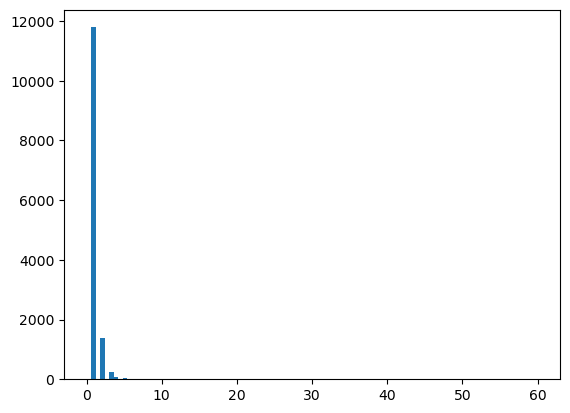

In [12]:
plt.hist(data['landmark_id'], bins=100, range=(0, 60), label = 'test')
plt.show()

In [13]:
data['landmark_id'].between(0,5).sum()

13549

In [14]:
data['landmark_id'].between(5,10).sum()

69

(array([1., 2., 1., ..., 1., 1., 5.]),
 array([0.00000e+00, 2.70000e+01, 3.00000e+01, ..., 2.03062e+05,
        2.03071e+05, 2.03073e+05]),
 <BarContainer object of 13588 artists>)

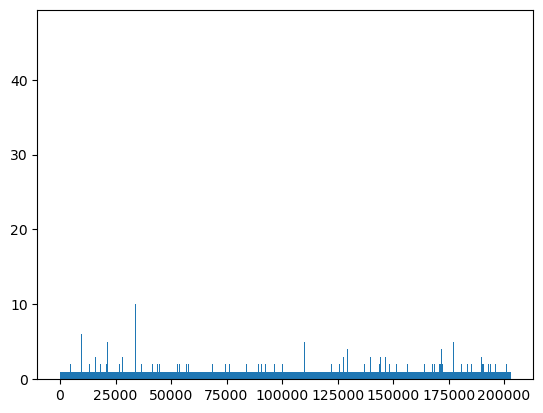

In [15]:
plt.hist(df["landmark_id"],bins=np.sort(df["landmark_id"].unique()))

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df['landmark_id'])

LabelEncoder()

In [17]:
def encode_label(lbl):
  return lencoder.transform(lbl)

In [18]:
def encode_label(lbl):
  return lencoder.inverse_transform(lbl)

In [19]:
def get_image_from_number(num):
    fname, label = df.loc[num, :]
    fname = fname + '.jpg'
    f1 = fname[0]
    f2 = fname[1]
    f3 = fname[2]
    path = os.path.join('/', f1, f2, f3, fname)
    img = cv2.imread(os.path.join(base_path, path))
    return img, label

In [20]:
print("4 Sample Images from random classes")
fig = plt.figure(figsize=(16, 16))
for i in range(1, 5):
        # Corrected path to the image directory
        ri = random.choice(os.listdir(base_path), k=3)
        folder = base_path + '/' + ri[0] + '/' + ri[1] + '/' + ri[2]
        ri = random.choice(os.listdir(ri))
        # Assuming images are in the format 'id.jpg'
        image_path = os.path.join(ri, random.choice(os.listdir(ri)))
        img = np.array(Image.open(folder+'/'+random_img))
        fig.add_subplot(1, 4, i)
        plt.imshow(img)
        plt.axis('off')
plt.show()

4 Sample Images from random classes


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Downloads/New folder/train.csv'

<Figure size 1600x1600 with 0 Axes>